In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("../data/loan_data_clean.csv")

In [3]:
print(f"Data loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print("\nExisting columns:")
for col in df.columns:
    print(f"  - {col}")

Data loaded: 120,262 rows x 12 columns

Existing columns:
  - Unnamed: 0
  - SeriousDlqin2yrs
  - RevolvingUtilizationOfUnsecuredLines
  - age
  - NumberOfTime30-59DaysPastDueNotWorse
  - DebtRatio
  - MonthlyIncome
  - NumberOfOpenCreditLinesAndLoans
  - NumberOfTimes90DaysLate
  - NumberRealEstateLoansOrLines
  - NumberOfTime60-89DaysPastDueNotWorse
  - NumberOfDependents


In [4]:
#Feature 1: Monthly Debt Amount
df['Monthlydept']=df['DebtRatio']*df['MonthlyIncome']
print(df['Monthlydept'].describe().round(2))

count    120262.00
mean       1926.59
std        1757.93
min           0.00
25%         571.95
50%        1571.62
75%        2792.56
max       16466.37
Name: Monthlydept, dtype: float64


In [5]:
#Feature 2: Income Per Dependent
df['IncomePerDependent']=(df['MonthlyIncome']/df['NumberOfDependents']+1)
print(df["IncomePerDependent"].describe().round(2))

count    119191.0
mean          inf
std           NaN
min           1.0
25%        4101.0
50%           NaN
75%           NaN
max           inf
Name: IncomePerDependent, dtype: float64


C:\Users\Dell\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


In [6]:
#Feature 3: Total Time Late
df['TotalTimeLate']=df['NumberOfTimes90DaysLate']+df["NumberOfTime30-59DaysPastDueNotWorse"]+df["NumberOfTime60-89DaysPastDueNotWorse"]
print(df['TotalTimeLate'].value_counts().head(10))

TotalTimeLate
0    94827
1    15289
2     6662
3     2492
4      992
Name: count, dtype: int64


In [7]:
#Feature 4: High Risk Flag
df['HighRiskFlag']=((df['NumberOfTimes90DaysLate']>=1) & (df['DebtRatio']>0.4)).astype(int)
print(df["HighRiskFlag"].value_counts())

HighRiskFlag
0    118124
1      2138
Name: count, dtype: int64


In [8]:
#Feature 5: Age Group
df['AgeGroup']=pd.cut(df['age'],bins=[0, 25, 35, 50, 65, 110],
    labels=["Very Young", "Young", "Middle", "Senior", "Elderly"]
)
print(df["AgeGroup"].value_counts())


AgeGroup
Middle        41259
Senior        40342
Elderly       20268
Young         15970
Very Young     2423
Name: count, dtype: int64


In [9]:
#Feature 6: Credit Utilization Category
df['CreditUtilCategory']=pd.cut(df['RevolvingUtilizationOfUnsecuredLines'], bins=[-1, 0.3, 0.6, 0.9, float('inf')],
    labels=["Low", "Medium", "High", "Very High"])
print(df["CreditUtilCategory"].value_counts())

CreditUtilCategory
Low          72181
Medium       19003
Very High    15833
High         13245
Name: count, dtype: int64


In [10]:
# One-hot encode categorical columns
df = pd.get_dummies(
    df,
    columns=["AgeGroup", "CreditUtilCategory"],
    drop_first=True  # avoids duplicate information
)
df

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,...,IncomePerDependent,TotalTimeLate,HighRiskFlag,AgeGroup_Young,AgeGroup_Middle,AgeGroup_Senior,AgeGroup_Elderly,CreditUtilCategory_Medium,CreditUtilCategory_High,CreditUtilCategory_Very High
0,1,1,0.766127,45,2,0.802982,9120.00,13,0,3,...,4561.0,2,0,False,True,False,False,False,True,False
1,2,0,0.957151,40,0,0.121876,2600.00,4,0,0,...,2601.0,0,0,False,True,False,False,False,False,True
2,3,0,0.658180,38,1,0.085113,3042.00,2,1,0,...,inf,2,0,False,True,False,False,False,True,False
3,4,0,0.233810,30,0,0.036050,3300.00,5,0,0,...,inf,0,0,True,False,False,False,False,False,False
4,5,0,0.907239,49,1,0.024926,14587.95,7,0,1,...,inf,1,0,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120257,149995,0,0.385742,50,0,0.404293,3400.00,7,0,0,...,inf,0,0,False,True,False,False,True,False,False
120258,149996,0,0.040674,74,0,0.225131,2100.00,4,0,1,...,inf,0,0,False,False,False,True,False,False,False
120259,149997,0,0.299745,44,0,0.716562,5584.00,4,0,1,...,2793.0,0,0,False,True,False,False,False,False,False
120260,149999,0,0.000000,30,0,0.000000,5716.00,4,0,0,...,inf,0,0,True,False,False,False,False,False,False


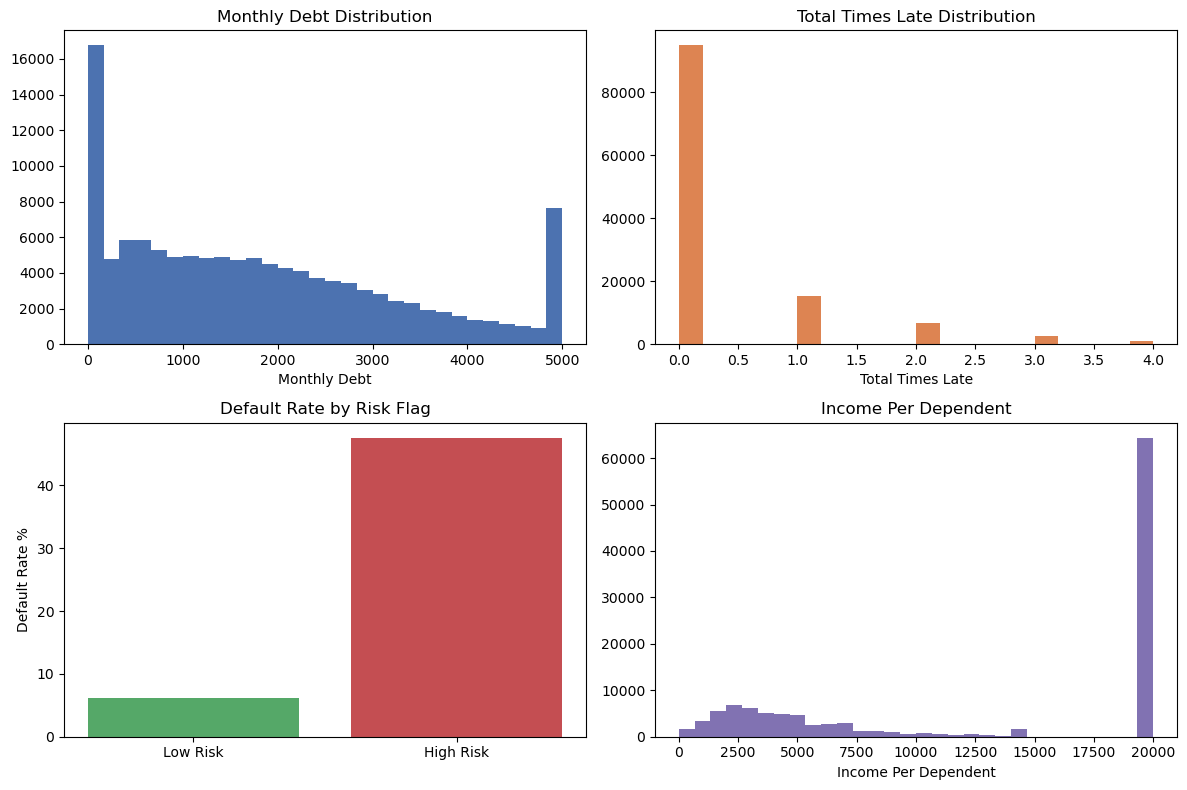

Chart saved to outputs/


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Monthly Debt distribution
axes[0,0].hist(df["Monthlydept"].clip(upper=5000), bins=30, color="#4C72B0")
axes[0,0].set_title("Monthly Debt Distribution")
axes[0,0].set_xlabel("Monthly Debt")

# Total Times Late
axes[0,1].hist(df["TotalTimeLate"], bins=20, color="#DD8452")
axes[0,1].set_title("Total Times Late Distribution")
axes[0,1].set_xlabel("Total Times Late")

# High Risk Flag vs Default Rate
default_by_risk = df.groupby("HighRiskFlag")["SeriousDlqin2yrs"].mean() * 100
axes[1,0].bar(["Low Risk", "High Risk"], default_by_risk.values, color=["#55A868", "#C44E52"])
axes[1,0].set_title("Default Rate by Risk Flag")
axes[1,0].set_ylabel("Default Rate %")

# Income Per Dependent
axes[1,1].hist(df["IncomePerDependent"].clip(upper=20000), bins=30, color="#8172B2")
axes[1,1].set_title("Income Per Dependent")
axes[1,1].set_xlabel("Income Per Dependent")

plt.tight_layout()
plt.savefig("../outputs/day4_features.png")
plt.show()
print("Chart saved to outputs/")

In [12]:
#Save final dataset
print(f"Final dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nOriginal columns : 11")
print(f"New columns added: {df.shape[1] - 11}")




Final dataset shape: 120,262 rows x 23 columns

Original columns : 11
New columns added: 12


In [13]:
# Save for Day 5 — SMOTE and model training
df.to_csv("../data/loan_data_features.csv", index=False)
print("\nSaved to data/loan_data_features.csv")
print("Day 4 complete!")


Saved to data/loan_data_features.csv
Day 4 complete!


In [14]:
df

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,...,IncomePerDependent,TotalTimeLate,HighRiskFlag,AgeGroup_Young,AgeGroup_Middle,AgeGroup_Senior,AgeGroup_Elderly,CreditUtilCategory_Medium,CreditUtilCategory_High,CreditUtilCategory_Very High
0,1,1,0.766127,45,2,0.802982,9120.00,13,0,3,...,4561.0,2,0,False,True,False,False,False,True,False
1,2,0,0.957151,40,0,0.121876,2600.00,4,0,0,...,2601.0,0,0,False,True,False,False,False,False,True
2,3,0,0.658180,38,1,0.085113,3042.00,2,1,0,...,inf,2,0,False,True,False,False,False,True,False
3,4,0,0.233810,30,0,0.036050,3300.00,5,0,0,...,inf,0,0,True,False,False,False,False,False,False
4,5,0,0.907239,49,1,0.024926,14587.95,7,0,1,...,inf,1,0,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120257,149995,0,0.385742,50,0,0.404293,3400.00,7,0,0,...,inf,0,0,False,True,False,False,True,False,False
120258,149996,0,0.040674,74,0,0.225131,2100.00,4,0,1,...,inf,0,0,False,False,False,True,False,False,False
120259,149997,0,0.299745,44,0,0.716562,5584.00,4,0,1,...,2793.0,0,0,False,True,False,False,False,False,False
120260,149999,0,0.000000,30,0,0.000000,5716.00,4,0,0,...,inf,0,0,True,False,False,False,False,False,False


In [15]:
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)


df = df.loc[:, ~df.columns.duplicated()]


bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print(f"Final shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print("Any duplicates?", df.columns.duplicated().any())
print("Any booleans?", len(df.select_dtypes(include='bool').columns))



Final shape: 120,262 rows x 22 columns
Any duplicates? False
Any booleans? 0


In [16]:
print(f"Total columns: {df.shape[1]}")
print("\nAll columns:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

Total columns: 22

All columns:
1. SeriousDlqin2yrs
2. RevolvingUtilizationOfUnsecuredLines
3. age
4. NumberOfTime30-59DaysPastDueNotWorse
5. DebtRatio
6. MonthlyIncome
7. NumberOfOpenCreditLinesAndLoans
8. NumberOfTimes90DaysLate
9. NumberRealEstateLoansOrLines
10. NumberOfTime60-89DaysPastDueNotWorse
11. NumberOfDependents
12. Monthlydept
13. IncomePerDependent
14. TotalTimeLate
15. HighRiskFlag
16. AgeGroup_Young
17. AgeGroup_Middle
18. AgeGroup_Senior
19. AgeGroup_Elderly
20. CreditUtilCategory_Medium
21. CreditUtilCategory_High
22. CreditUtilCategory_Very High


In [17]:

df.rename(columns={
    "Monthlydept": "MonthlyDebt",      # dept → debt
    "TotalTimeLate": "TotalTimesLate"  # Time → Times
}, inplace=True)

print("Column names fixed!")
print(df.columns.tolist())
df.to_csv("../data/loan_data_features.csv", index=False)

Column names fixed!
['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'MonthlyDebt', 'IncomePerDependent', 'TotalTimesLate', 'HighRiskFlag', 'AgeGroup_Young', 'AgeGroup_Middle', 'AgeGroup_Senior', 'AgeGroup_Elderly', 'CreditUtilCategory_Medium', 'CreditUtilCategory_High', 'CreditUtilCategory_Very High']
